In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ast
import seaborn as sns
import json
import glob
import random
from copy import deepcopy
from pathlib import Path
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, to_rgb, to_rgba


from Fitting_algo_v4 import *
from ECM_impedance_v3 import *
from utils import *

In [5]:
battery_json_file = "../EVC_EIS_Data/original_data/Battery_Info_DRT.json" # Check the path

with open(battery_json_file, "r") as f:
    battery_metadata = json.load(f)   # <--- this is now a dict


COLOR_MAP = build_cell_colormap(battery_metadata)

# SOH Regression

SOH ~(R0,R1,R2,R3, SOC) -- Categorical on Temperature

In [18]:
# ==========================================
# Final OLS model mirroring Lasso selection
# ==========================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# -------------------------------------------------
# 0) df must contain: SOH, R0, R1, R2, R3, SOC, Temp
#    Temp values are categorical levels (0, 25, 45)
# -------------------------------------------------
# df = df_global.copy()
df = pd.read_csv("df_global_median.csv")

# 1) Standardize continuous predictors (z-score)
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)


for col in ["R0", "R1", "R2", "R3", "SOC"]:
    df[f"{col}_z"] = zscore(df[col])

# Keep training stats to reuse on new data
train_means = {c: df[c].mean() for c in ["R0","R1","R2","R3","SOC"]}
train_stds  = {c: df[c].std(ddof=0) for c in ["R0","R1","R2","R3","SOC"]}


# 2) Build explicit dummies (25 °C is reference)
tmp = pd.get_dummies(df["Temp"].astype(int), prefix="Temp")
for need in ["Temp_0", "Temp_25", "Temp_45"]:
    if need not in tmp.columns:
        tmp[need] = 0
df = df.join(tmp[["Temp_0", "Temp_45"]])  # Temp_25 is dropped => reference group

for col in ["Temp_0","Temp_45"]:
    df[col] = df[col].astype(int)

# 3) Strict final formula 

# NOTE: Test all cross terms
final_formula_strict = (
    "SOH ~ R0_z + R1_z + R2_z + R3_z + SOC_z"
    "+ Temp_0 + Temp_45 "
    "+ R0_z:Temp_0 + R1_z:Temp_0 + R2_z:Temp_0 + R3_z:Temp_0 + SOC_z:Temp_0 "
    "+ R0_z:Temp_45 + R1_z:Temp_45 + R2_z:Temp_45 + R3_z:Temp_45 + SOC_z:Temp_45"
)

# Lasso return
# final_formula_strict = (
#     "SOH ~ R0_z + R1_z + R2_z + SOC_z"
#     "+ Temp_0"
#     "+ R0_z:Temp_0 +  R2_z:Temp_0 +  SOC_z:Temp_0 "
#     "+ R0_z:Temp_45 + R3_z:Temp_45 + SOC_z:Temp_45"
# )

# Lasso return + add back single predictor used in cross
# final_formula_strict = (
#     "SOH ~ R0_z + R1_z + R2_z + R3_z + SOC_z"
#     "+ Temp_0 + Temp_45"
#     "+ R0_z:Temp_0 +  R2_z:Temp_0 +  SOC_z:Temp_0 "
#     "+ R0_z:Temp_45 + R3_z:Temp_45 + SOC_z:Temp_45"
# )

# 4) Fit OLS
ols = smf.ols(final_formula_strict, data=df).fit()
print("\n=== OLS (classical SEs) ===")
print(ols.summary())

# Optional: robust standard errors (HC3)
ols_hc3 = ols.get_robustcov_results(cov_type="HC3")
print("\n=== OLS with robust (HC3) SEs ===")
print(ols_hc3.summary())

# 5) Read off per-temperature equations (intercepts and slopes)
p = ols.params  # coefficients as a pandas Series

# Baseline = 25 °C (Temp_0=0, Temp_45=0)
intercept_25 = p.get("Intercept", 0.0)
slopes_25 = {
    "R0_z": p.get("R0_z", 0.0),
    "R1_z": p.get("R1_z", 0.0),
    "R2_z": p.get("R2_z", 0.0),
    "R3_z": p.get("R3_z", 0.0),               # not selected at baseline
    "SOC_z": p.get("SOC_z", 0.0),              # not selected at baseline
}

# 0 °C (Temp_0=1, Temp_45=0)
intercept_0 = intercept_25 + p.get("Temp_0", 0.0)
slopes_0 = {
    "R0_z": slopes_25["R0_z"] + p.get("R0_z:Temp_0", 0.0),                         # no interaction at 0 → same as baseline
    "R1_z": slopes_25["R1_z"] + p.get("R1_z:Temp_0", 0.0),
    "R2_z": slopes_25["R2_z"] + p.get("R2_z:Temp_0", 0.0),
    "R3_z": slopes_25["R3_z"] + p.get("R3_z:Temp_0", 0.0),                                       # we intentionally dropped R3_z:Temp_0
    "SOC_z": slopes_25["SOC_z"] + p.get("SOC_z:Temp_0", 0.0),
}

# 45 °C (Temp_0=0, Temp_45=1)
intercept_45 = intercept_25 + p.get("Temp_45", 0.0)
slopes_45 = {
    "R0_z": slopes_25["R0_z"] + p.get("R0_z:Temp_45", 0.0),
    "R1_z": slopes_25["R1_z"] + p.get("R1_z:Temp_45", 0.0),                         # no R1_z:Temp_45 term
    "R2_z": slopes_25["R2_z"] + p.get("R2_z:Temp_45", 0.0),
    "R3_z": slopes_25["R3_z"] + p.get("R3_z:Temp_45", 0.0),
    "SOC_z": slopes_25["SOC_z"] + p.get("SOC_z:Temp_45", 0.0),
}

print("\n--- Per-temperature linear forms (in z-scored predictors) ---")
print(f"Temp=25°C: SOH = {intercept_25:+.4f}"
      f" + {slopes_25['R0_z']:+.4f}*R0_z"
      f" + {slopes_25['R1_z']:+.4f}*R1_z"
      f" + {slopes_25['R2_z']:+.4f}*R2_z"
      f" + {slopes_25['R3_z']:+.4f}*R3_z"
      f" + {slopes_25['SOC_z']:+.4f}*SOC_z")

print(f"Temp=0°C:  SOH = {intercept_0:+.4f}"
      f" + {slopes_0['R0_z']:+.4f}*R0_z"
      f" + {slopes_0['R1_z']:+.4f}*R1_z"
      f" + {slopes_0['R2_z']:+.4f}*R2_z"
      f" + {slopes_0['R3_z']:+.4f}*R3_z"
      f" + {slopes_0['SOC_z']:+.4f}*SOC_z")

print(f"Temp=45°C: SOH = {intercept_45:+.4f}"
      f" + {slopes_45['R0_z']:+.4f}*R0_z"
      f" + {slopes_45['R1_z']:+.4f}*R1_z"
      f" + {slopes_45['R2_z']:+.4f}*R2_z"
      f" + {slopes_45['R3_z']:+.4f}*R3_z"
      f" + {slopes_45['SOC_z']:+.4f}*SOC_z")

# 6) Predict on new data (make sure you have the same columns!)
# Example: predict on the training df itself
df["_pred_OLS"] = ols.predict(df)
train_pred = ols.get_prediction(df)
train_sf   = train_pred.summary_frame(alpha=0.05)
df["_pred_OLS_mean_ci_lower"] = train_sf["mean_ci_lower"].values
df["_pred_OLS_mean_ci_upper"] = train_sf["mean_ci_upper"].values

# Choose ONE of the two blocks below:

# (A) 95% Confidence Interval for the MEAN response:
# df["_ci_low"]  = train_sf["mean_ci_lower"].values
# df["_ci_high"] = train_sf["mean_ci_upper"].values

# # (B) 95% Prediction Interval for an INDIVIDUAL observation:
df["_ci_low"]  = train_sf["obs_ci_lower"].values
df["_ci_high"] = train_sf["obs_ci_upper"].values

# error bar distances above/below the point (asymmetric allowed)
df["_yerr_low"]  = (df["_pred_OLS"] - df["_ci_low"]).clip(lower=0)
df["_yerr_high"] = (df["_ci_high"] - df["_pred_OLS"]).clip(lower=0)
df.to_csv("df_global_median_with_preds.csv", index=False)



# 7) Helper to prepare ANY new dataframe using TRAINING stats
def prepare_new_rows(raw_df):
    out = raw_df.copy()

    # Ensure numeric types
    for c in ["R0","R1","R2","R3","SOC","Temp"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    # z-scores using TRAINING means/stds
    for c in ["R0","R1","R2","R3","SOC"]:
        out[f"{c}_z"] = (out[c] - train_means[c]) / train_stds[c]

    # Temp dummies (align to training design: 25°C reference)
    tmp_new = pd.get_dummies(out["Temp"].astype("Int64"), prefix="Temp")
    for need in ["Temp_0","Temp_25","Temp_45"]:
        if need not in tmp_new.columns:
            tmp_new[need] = 0
    out = out.join(tmp_new[["Temp_0","Temp_45"]])
    out["Temp_0"]  = out["Temp_0"].fillna(0).astype(int)
    out["Temp_45"] = out["Temp_45"].fillna(0).astype(int)

    return out

# 8) Load new data and predict
new_df = pd.read_csv("df_global_all.csv")

new_prepared = prepare_new_rows(new_df)
new_df["_pred_OLS_mean"] = ols.predict(new_prepared)

# (Optional) prediction intervals on new data (95% by default)
pred_res = ols.get_prediction(new_prepared)
pred_sf  = pred_res.summary_frame(alpha=0.05)  # columns: mean, mean_ci_lower/upper, obs_ci_lower/upper
new_df["_pred_OLS_mean_ci_lower"] = pred_sf["mean_ci_lower"].values
new_df["_pred_OLS_mean_ci_upper"] = pred_sf["mean_ci_upper"].values
new_df["_pred_OLS_obs_ci_lower"]  = pred_sf["obs_ci_lower"].values
new_df["_pred_OLS_obs_ci_upper"]  = pred_sf["obs_ci_upper"].values

# 9) (Optional) if SOH present in global_all.csv, evaluate quickly
if "SOH" in new_df.columns:
    from sklearn.metrics import r2_score, mean_absolute_error
    mask = new_df["_pred_OLS_mean"].notna() & new_df["SOH"].notna()
    if mask.any():
        r2  = r2_score(new_df.loc[mask,"SOH"], new_df.loc[mask,"_pred_OLS_mean"])
        mae = mean_absolute_error(new_df.loc[mask,"SOH"], new_df.loc[mask,"_pred_OLS_mean"])
        print(f"\n[New data] R^2 = {r2:.4f}, MAE = {mae:.4f}")

# 8) Save predictions
new_df.to_csv("global_all_with_ols_preds.csv", index=False)
print("\nSaved predictions to global_all_with_ols_preds.csv")


=== OLS (classical SEs) ===
                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     180.5
Date:                Fri, 10 Oct 2025   Prob (F-statistic):          9.32e-118
Time:                        12:35:41   Log-Likelihood:                 162.07
No. Observations:                 235   AIC:                            -288.1
Df Residuals:                     217   BIC:                            -225.9
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        

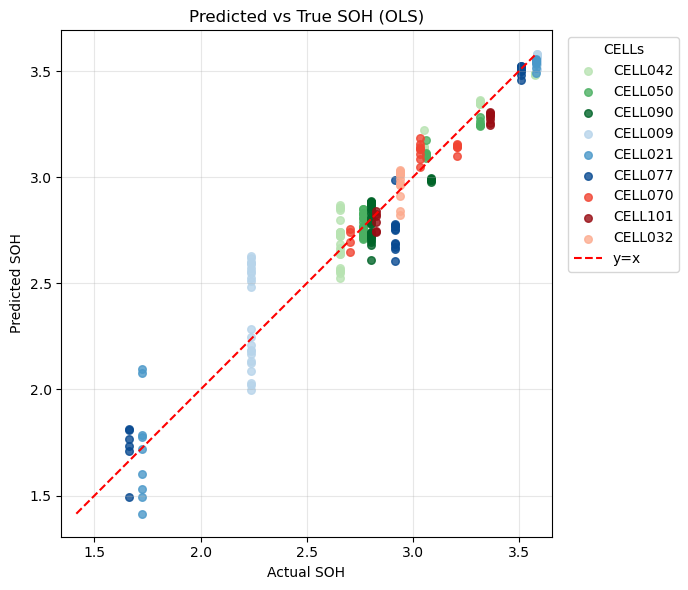

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# scatter by cell
for cell in df["CELL"].unique():   # <-- adjust column name if it's different
    sub = df[df["CELL"] == cell]
    plt.scatter(
        sub["SOH"], sub["_pred_OLS"],
        alpha=0.8, s=30, label=cell, color=COLOR_MAP[cell]
    )

# plt.scatter(g["SOH"], g["SOH_hat"], label=cell, alpha=0.8, s=30, color=COLOR_MAP[cell])

# 45° reference line
lims = [min(df["SOH"].min(), df["_pred_OLS"].min()),
        max(df["SOH"].max(), df["_pred_OLS"].max())]
plt.plot(lims, lims, "r--",  label="y=x")

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (OLS)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="CELLs")  # put legend outside
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()


In [20]:
df_fetch = df.copy()

print(df_fetch.loc[df["CELL"] == "CELL021", ["CELL", "SOH", "_pred_OLS", "SOC"]].sort_values(by="_pred_OLS", ascending=False))

        CELL      SOH  _pred_OLS       SOC
154  CELL021  3.58134   3.556462  0.496745
155  CELL021  3.58134   3.553172  0.413199
153  CELL021  3.58134   3.551637  0.580377
152  CELL021  3.58134   3.542015  0.663956
156  CELL021  3.58134   3.541348  0.329646
151  CELL021  3.58134   3.531188  0.747579
150  CELL021  3.58134   3.516314  0.831153
149  CELL021  3.58134   3.491679  0.914789
157  CELL021  1.72403   2.096180  0.938268
158  CELL021  1.72403   2.075742  0.876479
159  CELL021  1.72403   1.786048  0.814727
160  CELL021  1.72403   1.777759  0.752971
161  CELL021  1.72403   1.717012  0.691253
162  CELL021  1.72403   1.600629  0.629537
163  CELL021  1.72403   1.529872  0.567822
164  CELL021  1.72403   1.492063  0.506084
165  CELL021  1.72403   1.414353  0.444360


Testset:

(21952, 21)


C:\Users\liuha\AppData\Local\Temp\ipykernel_62408\2890226078.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([lo, hi], [lo, hi], "r--", lw=1, color="red", label="y=x")


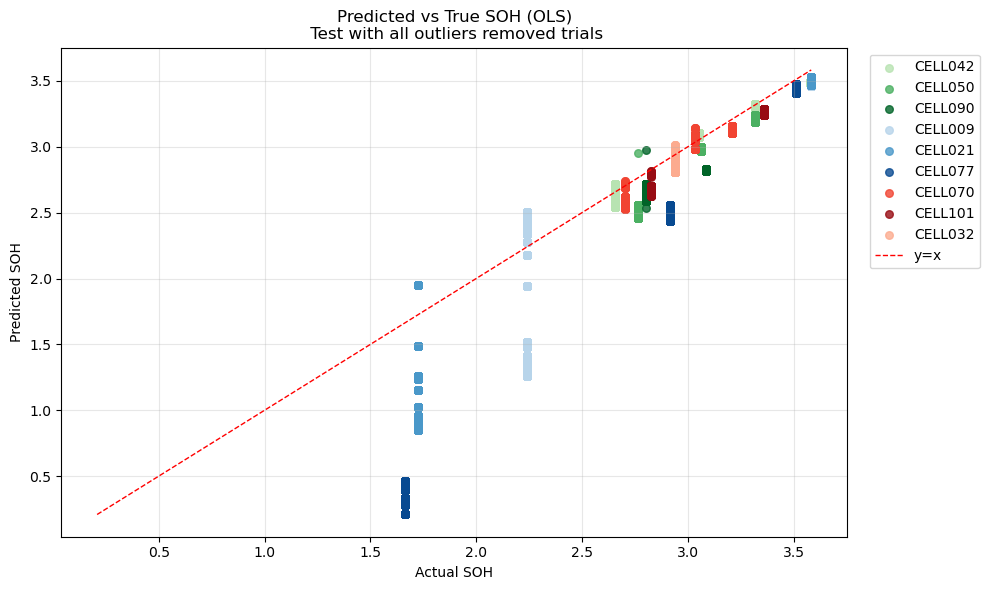

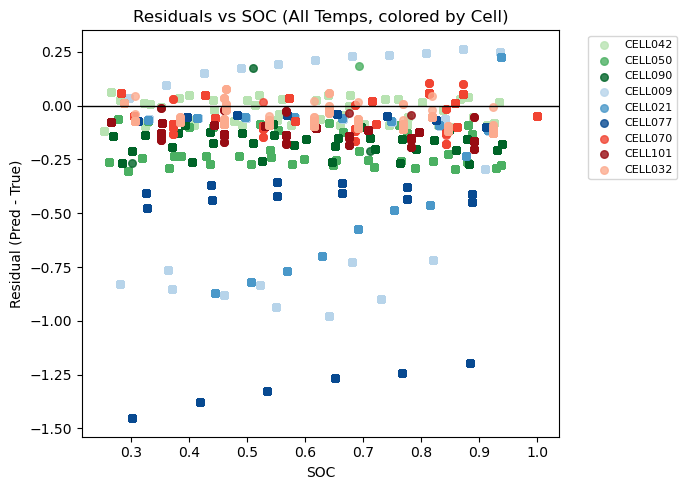

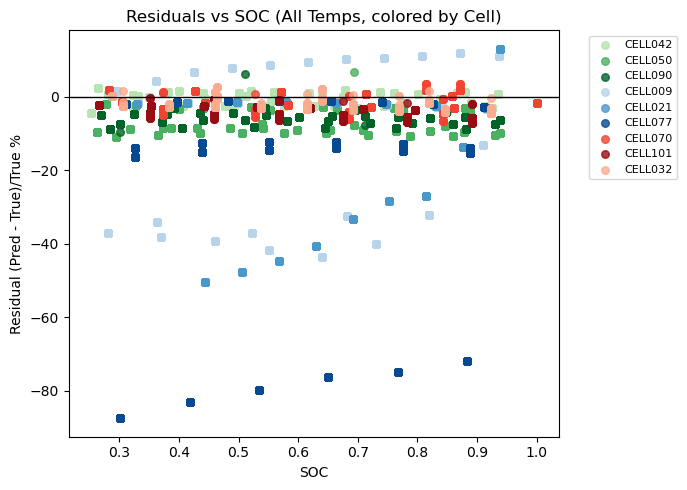

Test metrics — R^2: 0.4875, MAE: 0.2161
Saved annotated data with residuals to global_all_with_visualization_fields.csv


In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional

def load_testing_dataframe() -> Optional[pd.DataFrame]:
    if os.path.exists("global_all_with_ols_preds.csv"):
        return pd.read_csv("global_all_with_ols_preds.csv")
    if os.path.exists("df_global_all.csv"):
        return pd.read_csv("df_global_all.csv")
    return None

df = load_testing_dataframe()
print(df.shape)


if df is None:
    print("Could not find 'global_all_with_ols_preds.csv' or 'global_all.csv'.")
else:
    pred_col_candidates = ["_pred_OLS_mean", "pred", "prediction", "y_pred"]
    gt_col_candidates   = ["SOH", "y", "target"]
    temp_col_candidates = ["Temp", "temperature", "temp"]
    soc_col_candidates  = ["SOC", "soc"]

    pred_col = next((c for c in pred_col_candidates if c in df.columns), None)
    gt_col   = next((c for c in gt_col_candidates if c in df.columns), None)
    temp_col = next((c for c in temp_col_candidates if c in df.columns), None)
    soc_col  = next((c for c in soc_col_candidates if c in df.columns), None)

    if pred_col is None:
        print("No prediction column found.")
    else:
        if gt_col is not None:
            df["_residual"] = df[pred_col] - df[gt_col]
            df["rel_residual"] = (df[pred_col] - df[gt_col])/df[gt_col] *100


        # 1) plot with colors by CELL
        if gt_col is not None and "CELL" in df.columns:
            plt.figure(figsize=(10,6))
            for cell in df["CELL"].unique():
                sub = df[df["CELL"] == cell]
                plt.scatter(
                    sub[gt_col], sub[pred_col],
                    alpha=0.8, s=30,
                    label=cell,
                    color=COLOR_MAP.get(cell, "gray")
                )
            lo = min(df[gt_col].min(), df[pred_col].min())
            hi = max(df[gt_col].max(), df[pred_col].max())
            plt.plot([lo, hi], [lo, hi], "r--", lw=1, color="red", label="y=x")

            plt.xlabel("Actual SOH")
            plt.ylabel("Predicted SOH")
            plt.title("Predicted vs True SOH (OLS)\n Test with all outliers removed trials")
            plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.grid(alpha=0.3)
            plt.tight_layout()
            # plt.xlim(0.5, 3.8)
            # plt.ylim(0.5, 3.8)

            plt.show()

        # 2) Residuals vs SOC (colored by CELL)
        if gt_col is not None and soc_col is not None and "_residual" in df.columns and "CELL" in df.columns:
            plt.figure(figsize=(7,5))
            for cell in df["CELL"].unique():
                sub = df[df["CELL"] == cell]
                plt.scatter(
                    sub[soc_col], sub["_residual"],
                    alpha=0.8, s=30,
                    label=cell,
                    color=COLOR_MAP.get(cell, "gray")
                )
            plt.axhline(0, color="black", lw=1)
            plt.xlabel("SOC")
            plt.ylabel("Residual (Pred - True)")
            plt.title("Residuals vs SOC (All Temps, colored by Cell)")
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
            plt.tight_layout()
            plt.show()

        # 3) Relative Residuals vs SOC (colored by CELL)
        if gt_col is not None and soc_col is not None and "_residual" in df.columns and "CELL" in df.columns:
            plt.figure(figsize=(7,5))
            for cell in df["CELL"].unique():
                sub = df[df["CELL"] == cell]
                plt.scatter(
                    sub[soc_col], sub["rel_residual"],
                    alpha=0.8, s=30,
                    label=cell,
                    color=COLOR_MAP.get(cell, "gray")
                )
            plt.axhline(0, color="black", lw=1)
            plt.xlabel("SOC")
            plt.ylabel("Residual (Pred - True)/True %")
            plt.title("Residuals vs SOC (All Temps, colored by Cell)")
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
            plt.tight_layout()
            plt.show()

        # You can still keep per-temperature residual plots & boxplots as before
        # (color them by CELL inside each temp group similarly if desired)

        # Quick metrics
        if gt_col is not None:
            from sklearn.metrics import r2_score, mean_absolute_error
            mask = df[pred_col].notna() & df[gt_col].notna()
            if mask.any():
                r2  = r2_score(df.loc[mask, gt_col], df.loc[mask, pred_col])
                mae = mean_absolute_error(df.loc[mask, gt_col], df.loc[mask, pred_col])
                print(f"Test metrics — R^2: {r2:.4f}, MAE: {mae:.4f}")

    if "_residual" in df.columns:
        out_path = "global_all_with_visualization_fields.csv"
        df.to_csv(out_path, index=False)
        print(f"Saved annotated data with residuals to {out_path}")


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Make a tidy dataframe from your dicts
slopes_df = pd.DataFrame([
    {"Predictor": k.replace("_z",""), "Temp": 25, "Coef_Value": v}
    for k, v in slopes_25.items()
] + [
    {"Predictor": k.replace("_z",""), "Temp": 0, "Coef_Value": v}
    for k, v in slopes_0.items()
] + [
    {"Predictor": k.replace("_z",""), "Temp": 45, "Coef_Value": v}
    for k, v in slopes_45.items()
])

print(slopes_df)

fig_dir = "SOH_Regression_Plots"
os.makedirs(fig_dir, exist_ok=True)

# Plot slope vs temperature for each predictor
for pred in slopes_df["Predictor"].unique():
    sub = slopes_df.query("Predictor == @pred").sort_values("Temp")
    plt.figure()
    plt.plot(sub["Temp"], sub["Coef_Value"], marker="o")
    # dashed line between first and last temperature point
    if len(sub) >= 2:
        t0, t1 = sub["Temp"].iloc[0], sub["Temp"].iloc[-1]
        s0, s1 = sub["Coef_Value"].iloc[0], sub["Coef_Value"].iloc[-1]
        plt.plot([t0, t1], [s0, s1], "k--", label=f"{t0}→{t1} trend")
    plt.title(f"Coefficient of {pred} vs Temperature")
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Coefficient")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks([0,25,45])
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/coef_vs_temp_{pred}.png", dpi=150)
    plt.close()


# --- Build tidy dataframe for intercepts (ordered 0 -> 25 -> 45) ---
intercepts_df = pd.DataFrame([
    {"Term": "Intercept", "Temp": 0,  "Coef_Value": intercept_0},
    {"Term": "Intercept", "Temp": 25, "Coef_Value": intercept_25},
    {"Term": "Intercept", "Temp": 45, "Coef_Value": intercept_45},
]).sort_values("Temp")


print(intercepts_df)

# --- Plot intercept vs temperature ---
plt.figure()
plt.plot(intercepts_df["Temp"], intercepts_df["Coef_Value"], marker="o", label="Intercept")

# dashed line connecting first and last
t0, t1 = intercepts_df["Temp"].iloc[0], intercepts_df["Temp"].iloc[-1]
s0, s1 = intercepts_df["Coef_Value"].iloc[0], intercepts_df["Coef_Value"].iloc[-1]
plt.plot([t0, t1], [s0, s1], "k--", label=f"{t0}→{t1} trend")

plt.title("Intercept vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Intercept")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks([0, 25, 45])
plt.tight_layout()
plt.savefig(f"{fig_dir}/intercept_vs_temp.png", dpi=150)
plt.close()


   Predictor  Temp  Coef_Value
0         R0    25   -0.309252
1         R1    25   -0.091604
2         R2    25   -0.133330
3         R3    25   -0.515363
4        SOC    25   -0.002133
5         R0     0   -0.276465
6         R1     0   -0.618856
7         R2     0   -1.368397
8         R3     0   -0.366289
9        SOC     0   -0.038658
10        R0    45   -0.169887
11        R1    45   -0.048246
12        R2    45   -0.053961
13        R3    45   -0.062898
14       SOC    45   -0.019078
        Term  Temp  Coef_Value
0  Intercept     0    0.987420
1  Intercept    25    2.792370
2  Intercept    45    3.063536


In [13]:
import matplotlib.ticker as mticker
# --- Combine slopes and intercept into one tidy df ---
slopes_df2 = slopes_df.rename(columns={"Slope": "Coef_Value"})
all_effects_df = pd.concat([slopes_df2, intercepts_df.rename(columns={"Term": "Predictor"})],
                           ignore_index=True)
all_effects_df.insert(2, "K", (273.15 + all_effects_df["Temp"]))
all_effects_df.insert(3, "1/K", 1.0 / (273.15 + all_effects_df["Temp"]))
all_effects_df.insert(4, "EXP(1/K)", np.exp(1.0 / (273.15 + all_effects_df["Temp"])))



print(all_effects_df)
all_effects_df.to_csv("all_effects_vs_temp.csv", index=False)


fig_dir = "SOH_Regression_Plots"
os.makedirs(fig_dir, exist_ok=True)
# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("Temp")
    plt.plot(sub["Temp"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks([0,25,45])
plt.ylim(-3.1, 3.1)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/coef_vs_temp_all.png", dpi=150)
plt.close()


# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("1/K")
    plt.plot(sub["1/K"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (1/K)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/coef_vs_tempK_all.png", dpi=150)
plt.close()


# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("1/K")
    plt.plot(sub["1/K"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (1/K)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/coef_vs_temp_1overK_all.png", dpi=150)
plt.close()


# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("K")
    plt.plot(sub["K"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (K)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/coef_vs_tempK_all.png", dpi=150)
plt.close()


# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("EXP(1/K)")
    plt.plot(sub["EXP(1/K)"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (EXP(1/K))")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
# Format ticks nicely: let matplotlib choose tick spacing, but show 4 decimals
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
plt.savefig(f"{fig_dir}/coef_vs_temp_exp1overK_all.png", dpi=150)
plt.close()



    Predictor  Temp       K       1/K  EXP(1/K)  Coef_Value
0          R0    25  298.15  0.003354  1.003360   -0.309252
1          R1    25  298.15  0.003354  1.003360   -0.091604
2          R2    25  298.15  0.003354  1.003360   -0.133330
3          R3    25  298.15  0.003354  1.003360   -0.515363
4         SOC    25  298.15  0.003354  1.003360   -0.002133
5          R0     0  273.15  0.003661  1.003668   -0.276465
6          R1     0  273.15  0.003661  1.003668   -0.618856
7          R2     0  273.15  0.003661  1.003668   -1.368397
8          R3     0  273.15  0.003661  1.003668   -0.366289
9         SOC     0  273.15  0.003661  1.003668   -0.038658
10         R0    45  318.15  0.003143  1.003148   -0.169887
11         R1    45  318.15  0.003143  1.003148   -0.048246
12         R2    45  318.15  0.003143  1.003148   -0.053961
13         R3    45  318.15  0.003143  1.003148   -0.062898
14        SOC    45  318.15  0.003143  1.003148   -0.019078
15  Intercept     0  273.15  0.003661  1

# R SOH Temp

In [20]:
def R_SOH_Temp_plot(R='R1'):
    df = pd.read_csv('df_global_median.csv')

    # Plot
    plt.figure(figsize=(8, 6))

    for cell, color in COLOR_MAP.items():
        cell_data = df[df['CELL'] == cell]
        if not cell_data.empty:
            plt.scatter(cell_data[R], cell_data['SOH'], label=cell, color=color, alpha=0.7)


    plt.xlabel(f'{R}')
    plt.ylabel('SOH')
    plt.title(f'SOH vs {R} by CELL')
    plt.legend(title='CELL')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot Average SOC

    # For each (CELL, SOH), take:
    # - mean of R
    agg_df = (
        df.groupby(['CELL', 'SOH'], as_index=False)
        .agg({R: 'mean'})
    )

    # Plot
    plt.figure(figsize=(8, 6))

    for cell, color in COLOR_MAP.items():
        cell_data = agg_df[agg_df['CELL'] == cell].sort_values(by='SOH')
        if not cell_data.empty:
            plt.plot(cell_data[R], cell_data['SOH'], color=color, label=cell,
                    linewidth=2, marker='o', markersize=6, alpha=0.8)

    plt.xlabel(f'{R} (average per SOH)')
    plt.ylabel('SOH')
    plt.title(f'SOH vs {R} by CELL ({R} averaged per SOH)')
    plt.legend(title='CELL')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


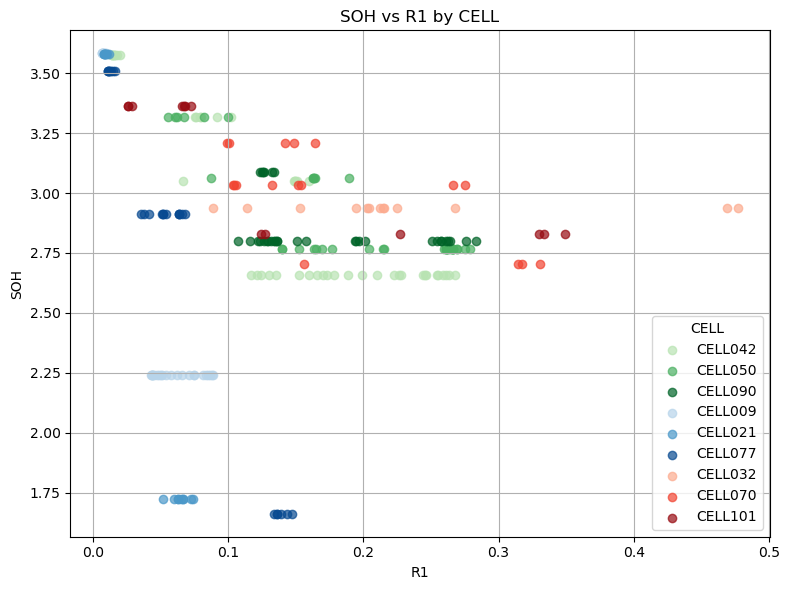

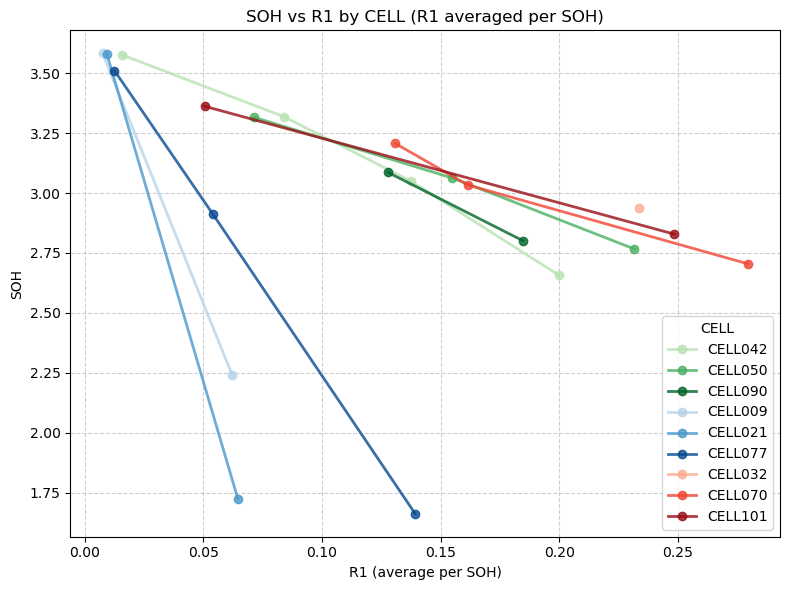

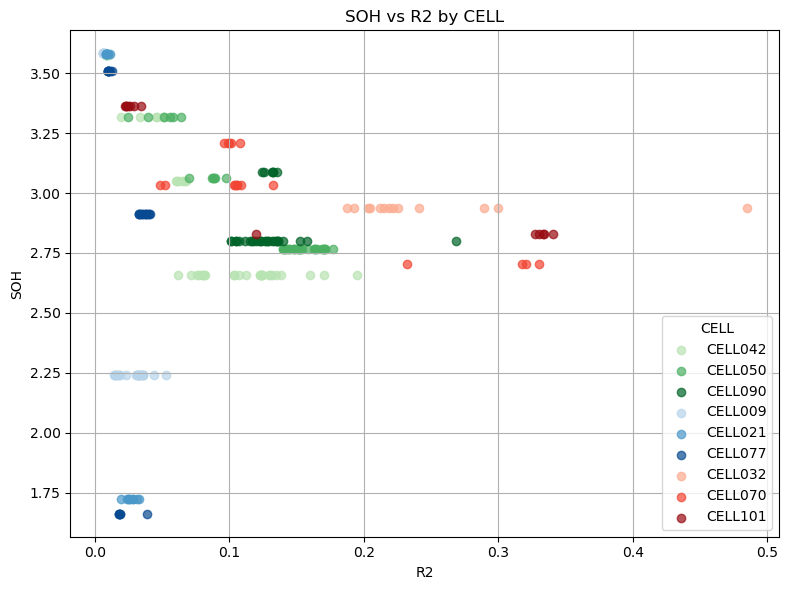

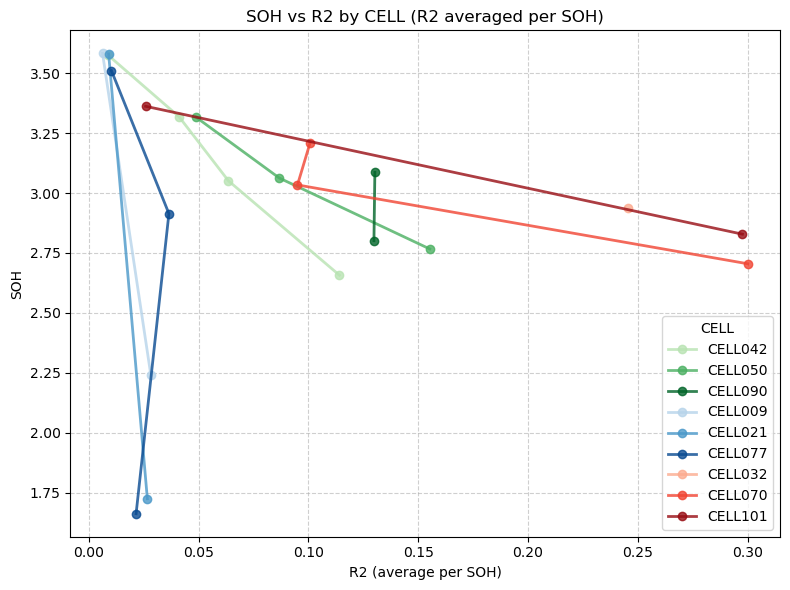

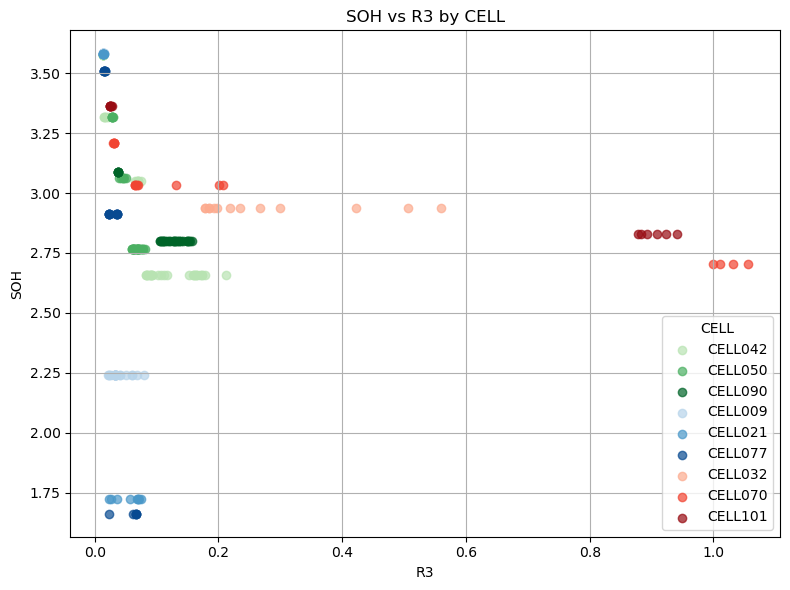

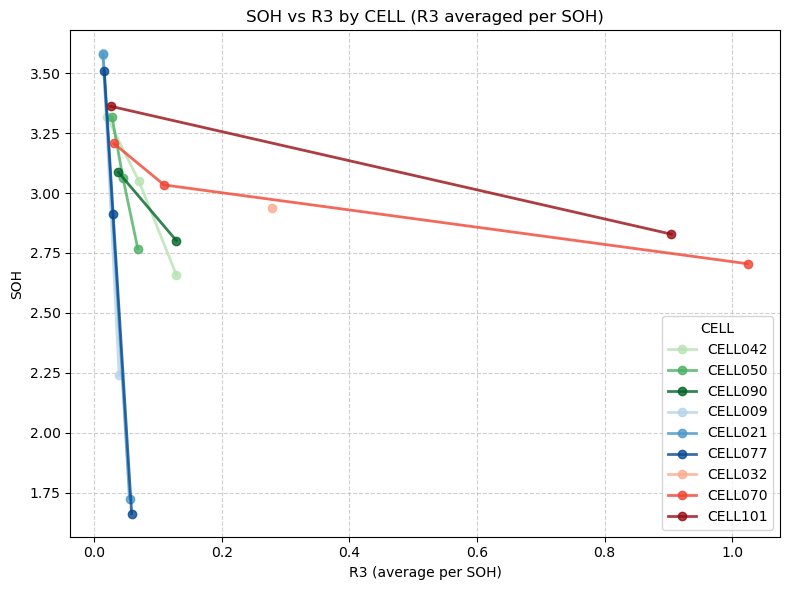

In [22]:
R_SOH_Temp_plot("R1")
R_SOH_Temp_plot("R2")
R_SOH_Temp_plot("R3")



# Model Exp

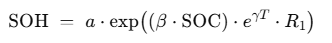

Fitted parameters: a=3.283, beta=-8.171, gamma=-0.07369


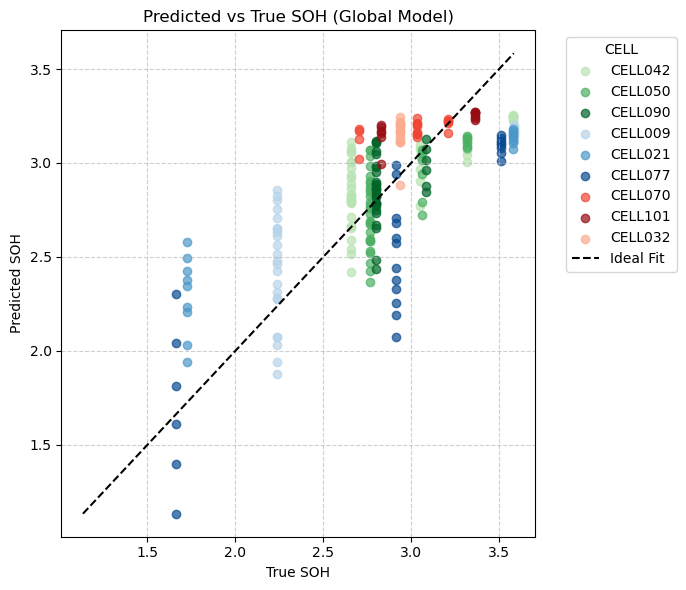

R² = 0.5821, RMSE = 0.3054


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Load data and define model
# ----------------------------
df = pd.read_csv("df_global_median.csv")
df = df[['CELL', 'Temp', 'R1', 'SOH', 'SOC']].dropna()

def soh_model(xdata, a, beta, gamma):
    R1, T, SOC = xdata
    return a * np.exp((beta * SOC) * np.exp(gamma * T) * R1)

R1_all  = df['R1'].to_numpy(float)
T_all   = df['Temp'].to_numpy(float)
SOC_all = df['SOC'].to_numpy(float)
y_true  = df['SOH'].to_numpy(float)

# ----------------------------
# Fit a single global model
# ----------------------------
p0 = [max(np.median(y_true), 1e-3), 1e-3, 0.0]
bounds = ([1e-12, -np.inf, -np.inf], [np.inf, np.inf, np.inf])

popt, _ = curve_fit(
    soh_model, 
    xdata=(R1_all, T_all, SOC_all), 
    ydata=y_true, 
    p0=p0, 
    bounds=bounds,
    maxfev=30000
)
a_hat, beta_hat, gamma_hat = popt
print(f"Fitted parameters: a={a_hat:.4g}, beta={beta_hat:.4g}, gamma={gamma_hat:.4g}")

# ----------------------------
# Predict SOH using fitted model
# ----------------------------
y_pred = soh_model((R1_all, T_all, SOC_all), a_hat, beta_hat, gamma_hat)

# ----------------------------
# Plot predicted vs true SOH
# ----------------------------
plt.figure(figsize=(7, 6))
cells = df['CELL'].unique()


for cell in cells:
    mask = df['CELL'] == cell
    plt.scatter(y_true[mask], y_pred[mask], color=COLOR_MAP[cell], alpha=0.7, label=cell)

# Add 1:1 reference line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', lw=1.5, label='Ideal Fit')

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (Global Model)")
plt.legend(title='CELL', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: compute fit metrics
# ----------------------------
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(f"R² = {r2:.4f}, RMSE = {rmse:.4f}")


(235,)
Fitted parameters: a=3.401, beta_1=-1.308, beta_2=0.1851, beta_3=-5.209, gamma=-0.06755


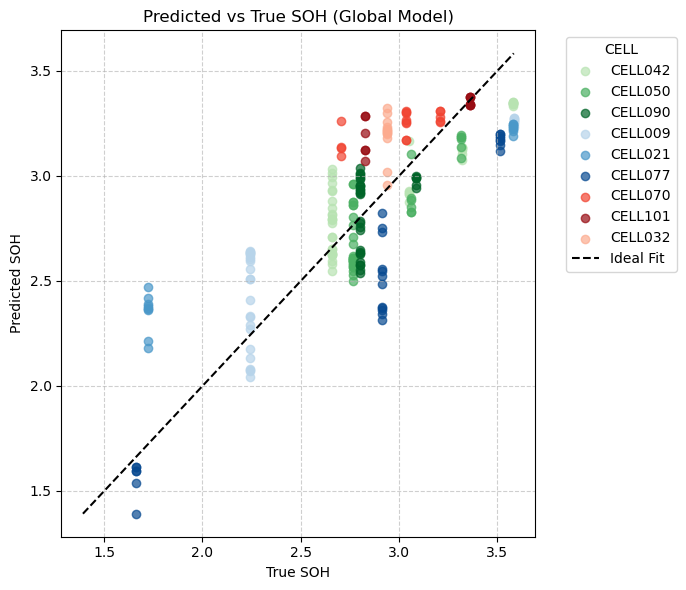

R² = 0.6731, RMSE = 0.2701


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Load data and define model
# ----------------------------
df = pd.read_csv("df_global_median.csv")
df = df[['CELL', 'Temp', 'R1', 'SOH', 'SOC']].dropna()

def soh_model(xdata, a, beta1, beta2, beta3, gamma):
    R1, T, SOC = xdata
    return a * np.exp((beta1 * SOC*SOC + beta2 * SOC + beta3) * np.exp(gamma * T) * R1)

R1_all  = df['R1'].to_numpy(float)
T_all   = df['Temp'].to_numpy(float)
SOC_all = df['SOC'].to_numpy(float)
y_true  = df['SOH'].to_numpy(float)
print(R1_all.shape)

# ----------------------------
# Fit a single global model
# ----------------------------
p0 = [max(np.median(y_true), 1), 1, 1, 1, 0.0]
bounds = ([1e-12, -np.inf, -np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf])

popt, _ = curve_fit(
    soh_model, 
    xdata=(R1_all, T_all, SOC_all), 
    ydata=y_true, 
    p0=p0, 
    bounds=bounds,
    maxfev=30000
)
a_hat, beta1_hat, beta2_hat, beta3_hat, gamma_hat = popt
print(f"Fitted parameters: a={a_hat:.4g}, beta_1={beta1_hat:.4g}, beta_2={beta2_hat:.4g}, beta_3={beta3_hat:.4g}, gamma={gamma_hat:.4g}")

# ----------------------------
# Predict SOH using fitted model
# ----------------------------
y_pred = soh_model((R1_all, T_all, SOC_all), a_hat, beta1_hat, beta2_hat, beta3_hat,gamma_hat)

# ----------------------------
# Plot predicted vs true SOH
# ----------------------------
plt.figure(figsize=(7, 6))
cells = df['CELL'].unique()


for cell in cells:
    mask = df['CELL'] == cell
    plt.scatter(y_true[mask], y_pred[mask], color=COLOR_MAP[cell], alpha=0.7, label=cell)

# Add 1:1 reference line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', lw=1.5, label='Ideal Fit')

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (Global Model)")
plt.legend(title='CELL', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: compute fit metrics
# ----------------------------
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(f"R² = {r2:.4f}, RMSE = {rmse:.4f}")


Fitted parameters: a=3.435, beta_1=0.1445, beta_2=-0.2621, beta_3=-0.2396, gamma=0.05015


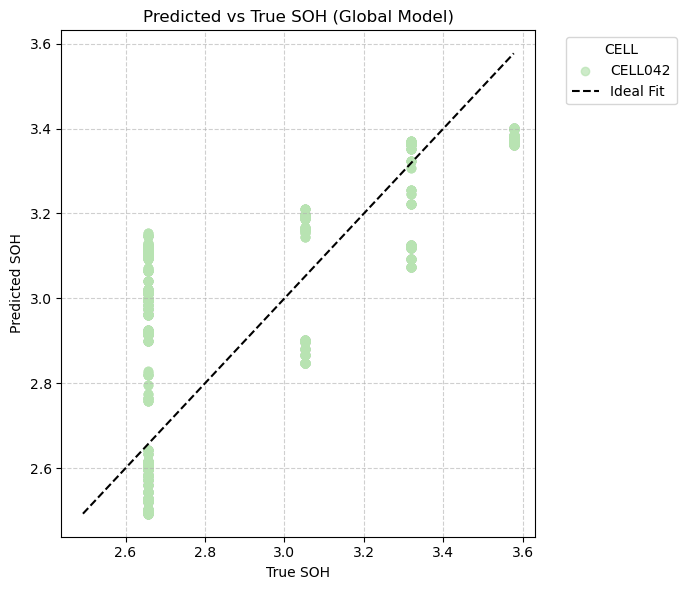

R² = 0.6230, RMSE = 0.2294


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Load data and define model
# ----------------------------
df = pd.read_csv("df_global_all.csv")
df = df[['CELL', 'Temp', 'R1', 'SOH', 'SOC']].dropna()
df = df[0:2000]

def soh_model(xdata, a, beta1, beta2, beta3, gamma):
    R1, T, SOC = xdata
    return a * np.exp((beta1 * SOC*SOC + beta2 * SOC + beta3) * np.exp(gamma * T) * R1)

R1_all  = df['R1'].to_numpy(float)
T_all   = df['Temp'].to_numpy(float)
SOC_all = df['SOC'].to_numpy(float)
y_true  = df['SOH'].to_numpy(float)

# ----------------------------
# Fit a single global model
# ----------------------------
p0 = [max(np.median(y_true), 1), 1, 1, 1, 0.0]
bounds = ([1e-12, -np.inf, -np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf])

popt, _ = curve_fit(
    soh_model, 
    xdata=(R1_all, T_all, SOC_all), 
    ydata=y_true, 
    p0=p0, 
    bounds=bounds,
    maxfev=30000
)
a_hat, beta1_hat, beta2_hat, beta3_hat, gamma_hat = popt
print(f"Fitted parameters: a={a_hat:.4g}, beta_1={beta1_hat:.4g}, beta_2={beta2_hat:.4g}, beta_3={beta3_hat:.4g}, gamma={gamma_hat:.4g}")

# ----------------------------
# Predict SOH using fitted model
# ----------------------------
y_pred = soh_model((R1_all, T_all, SOC_all), a_hat, beta1_hat, beta2_hat, beta3_hat,gamma_hat)

# ----------------------------
# Plot predicted vs true SOH
# ----------------------------
plt.figure(figsize=(7, 6))
cells = df['CELL'].unique()


for cell in cells:
    mask = df['CELL'] == cell
    plt.scatter(y_true[mask], y_pred[mask], color=COLOR_MAP[cell], alpha=0.7, label=cell)

# Add 1:1 reference line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', lw=1.5, label='Ideal Fit')

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (Global Model)")
plt.legend(title='CELL', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: compute fit metrics
# ----------------------------
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(f"R² = {r2:.4f}, RMSE = {rmse:.4f}")


In [38]:
R1_all.shape

(11580,)